<a href="https://colab.research.google.com/github/AdilM01/AI-Projects/blob/feature%2Fai-projects/Understanding_Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reinforcement Learning (RL)


# What is Reinforcement Learning?

Reinforcement Learning (RL) is a branch of Artificial Intelligence where an **agent learns by interacting with an environment**.

Unlike supervised learning, the agent is **not given the correct answer**.

Instead, it learns through:

- Trial
- Error
- Rewards
- Penalties

The objective is to learn the best sequence of actions that maximizes long-term reward.

---

# Human Learning Example

Imagine teaching a child to ride a bicycle.

The child:

✔ Falls down

✔ Learns balance

✔ Tries again

✔ Eventually succeeds

Nobody tells the child the exact angle to maintain.

Instead:

Action → Feedback → Improvement

This is Reinforcement Learning.

---


# Formal Definition

Reinforcement Learning is a learning paradigm where an intelligent agent learns an optimal policy by interacting with an environment to maximize cumulative reward.

---

# Components of RL

There are five fundamental components.

## 1. Agent

The learner.

Examples:

- Robot
- Game AI
- Self-driving car
- ChatGPT using RLHF
- Trading bot

---

## 2. Environment

Everything outside the agent.

Examples:

Chess board

Road

Video game

Robot world

Financial market

---

## 3. State (S)

The current situation of the environment.

Examples:

Robot position

Current chess board

Speed of a car

Current game screen

---

## 4. Action (A)

A decision made by the agent.

Examples:

Move Left

Move Right

Accelerate

Brake

Pick Object

Drop Object

---

## 5. Reward (R)

Feedback received after taking an action.

Positive Reward

+10

Negative Reward

-5

No Reward

0

The reward tells the agent whether the action was good or bad.

---

# RL Interaction Loop

                Reward
                  ↑
                  │
          +----------------+
          |                |
          | Environment    |
          |                |
          +----------------+
                 ▲
                 │ State
                 │
Action           │
──────►      +---------+
             | Agent   |
             +---------+

The loop repeats until the task ends.

---

# Goal of Reinforcement Learning

The goal is NOT to maximize today's reward.

The goal is to maximize the **total future reward**.

This is called:

## Cumulative Reward

Example

Immediate reward

+5

Later reward

+100

RL prefers long-term success instead of short-term gains.

---

# Everyday Examples

Google Maps

Chooses the best route.

Robot Navigation

Learns to avoid obstacles.

Tesla Autopilot

Learns driving policies.

Game AI

Learns to defeat players.

Stock Trading

Learns profitable strategies.

Recommendation Systems

Learns user preferences.

LLM Agents

Learn tool usage using rewards.

---

# Difference Between ML, DL and RL

| Machine Learning | Deep Learning | Reinforcement Learning |
|-----------------|--------------|-------------------------|
| Uses labeled data | Uses neural networks | Learns by interaction |
| Correct answers available | Correct answers available | No labels |
| Predicts outputs | Learns complex features | Learns actions |
| Classification | Image Recognition | Robotics |
| Regression | NLP | Games |

---

# Why RL is Difficult

The agent initially knows nothing.

It must discover:

- Which action is good
- Which action is bad
- Which action gives future rewards

This process is called exploration.

---

# Exploration vs Exploitation

Exploration

Trying new actions.

Example:

Trying a new restaurant.

Exploitation

Using the best-known action.

Example:

Going to your favorite restaurant.

A successful RL agent balances both.

---

# Reward Design

A poorly designed reward leads to poor behavior.

Example

Robot Reward

+100 Reach Goal

-100 Hit Wall

-1 Every Step

Without the step penalty, the robot may wander forever.

---

# Why RL Became Popular

RL has achieved state-of-the-art performance in:

- Chess
- Go
- Atari Games
- Robotics
- Drone Control
- Warehouse Automation
- ChatGPT (RLHF)
- Autonomous Vehicles



In [ ]:
print("=" * 60)
print("REINFORCEMENT LEARNING INTERACTION LOOP")
print("=" * 60)

agent = "🤖 Agent"
environment = "🌍 Environment"

state = "Start"

for step in range(5):

    print(f"\nStep {step+1}")

    print(f"Current State : {state}")

    action = "Move Right"

    print(f"Action Taken  : {action}")

    reward = 10 if step == 4 else -1

    next_state = f"State-{step+1}"

    print(f"Reward        : {reward}")

    print(f"Next State    : {next_state}")

    state = next_state

print("\nEpisode Finished")

REINFORCEMENT LEARNING INTERACTION LOOP

Step 1
Current State : Start
Action Taken  : Move Right
Reward        : -1
Next State    : State-1

Step 2
Current State : State-1
Action Taken  : Move Right
Reward        : -1
Next State    : State-2

Step 3
Current State : State-2
Action Taken  : Move Right
Reward        : -1
Next State    : State-3

Step 4
Current State : State-3
Action Taken  : Move Right
Reward        : -1
Next State    : State-4

Step 5
Current State : State-4
Action Taken  : Move Right
Reward        : 10
Next State    : State-5

Episode Finished


### **Step 1: Create the GridWorld Environment Class**

In [ ]:
class GridWorld:

    def __init__(self):

        self.size = 5

        self.goal = (4, 4)

        self.obstacles = [
            (1,1),
            (1,3),
            (3,0),
            (3,2)
        ]

        self.reset()

### **Step 2: Reset the Environment**

In [ ]:
def reset(self):

    self.agent = [0,0]

    return tuple(self.agent)

### **Step 3: Render the GridWorld**

In [ ]:
def render(self):

    print()

    for r in range(self.size):

        for c in range(self.size):

            if (r,c)==tuple(self.agent):

                print("A",end=" ")

            elif (r,c)==self.goal:

                print("G",end=" ")

            elif (r,c) in self.obstacles:

                print("X",end=" ")

            else:

                print(".",end=" ")

        print()

    print()


### **Step 4: Implement the Agent Movement (`step`) Function**

In [ ]:
def step(self, action):

    row, col = self.agent

    if action == 0:
        row -= 1

    elif action == 1:
        row += 1

    elif action == 2:
        col -= 1

    elif action == 3:
        col += 1
    row = max(0, min(self.size-1, row))
    col = max(0, min(self.size-1, col))

    if (row, col) in self.obstacles:

        row, col = self.agent

    self.agent = [row, col]


    reward = -1

    done = False

    if tuple(self.agent) == self.goal:

        reward = 100

        done = True

    return tuple(self.agent), reward, done

### **Step 5: Complete the GridWorld Environment**

In [ ]:
class GridWorld:

    def __init__(self):

        self.size = 5

        self.goal = (4,4)

        self.obstacles = [
            (1,1),
            (1,3),
            (3,0),
            (3,2)
        ]

        self.reset()

    def reset(self):

        self.agent = [0,0]

        return tuple(self.agent)

    def render(self):

        print()

        for r in range(self.size):

            for c in range(self.size):

                if (r,c)==tuple(self.agent):

                    print("A",end=" ")

                elif (r,c)==self.goal:

                    print("G",end=" ")

                elif (r,c) in self.obstacles:

                    print("X",end=" ")

                else:

                    print(".",end=" ")

            print()

        print()

    def step(self, action):

        row,col = self.agent

        if action==0:
            row -= 1

        elif action==1:
            row += 1

        elif action==2:
            col -= 1

        elif action==3:
            col += 1

        row = max(0,min(self.size-1,row))
        col = max(0,min(self.size-1,col))

        if (row,col) in self.obstacles:

            row,col = self.agent

        self.agent = [row,col]

        reward = -1
        done = False

        if tuple(self.agent)==self.goal:

            reward = 100
            done = True

        return tuple(self.agent), reward, done

### **Step 6: Create the Environment and Display the Initial Grid**

In [ ]:
env = GridWorld()

state = env.reset()

env.render()


A . . . . 
. X . X . 
. . . . . 
X . X . . 
. . . . G 



### **Step 7: Test the GridWorld Environment by Moving the Agent**

In [ ]:
actions = [
    3,  # Right
    3,  # Right
    1,  # Down
    1,  # Down
    3,  # Right
    1   # Down
]

for action in actions:

    state, reward, done = env.step(action)

    print("State :", state)
    print("Reward:", reward)

    env.render()

    if done:

        print("Goal Reached!")
        break

State : (0, 1)
Reward: -1

. A . . . 
. X . X . 
. . . . . 
X . X . . 
. . . . G 

State : (0, 2)
Reward: -1

. . A . . 
. X . X . 
. . . . . 
X . X . . 
. . . . G 

State : (1, 2)
Reward: -1

. . . . . 
. X A X . 
. . . . . 
X . X . . 
. . . . G 

State : (2, 2)
Reward: -1

. . . . . 
. X . X . 
. . A . . 
X . X . . 
. . . . G 

State : (2, 3)
Reward: -1

. . . . . 
. X . X . 
. . . A . 
X . X . . 
. . . . G 

State : (3, 3)
Reward: -1

. . . . . 
. X . X . 
. . . . . 
X . X A . 
. . . . G 



### **Step 8: Reinforcement Learning Intuition with a Random Agent in a Custom GridWorld**

In [ ]:
"""
===========================================
REINFORCEMENT LEARNING INTUITION
(Grid World - Pure Python)
No Gymnasium
No Q-Learning
===========================================
"""

import random
import os
import time

# -----------------------------
# Environment
# -----------------------------
ROWS = 5
COLS = 5

START = (0, 0)
GOAL = (4, 4)

WALLS = [
    (1, 2),
    (2, 2),
    (3, 1),
    (1, 4)
]

# Rewards
STEP_REWARD = -1
GOAL_REWARD = 10
WALL_REWARD = -5

ACTIONS = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1)
}


# -----------------------------
# Draw Environment
# -----------------------------
def draw(agent):

    os.system("cls" if os.name == "nt" else "clear")

    print("=" * 40)
    print(" SIMPLE GRID WORLD ")
    print("=" * 40)

    for r in range(ROWS):

        for c in range(COLS):

            pos = (r, c)

            if pos == agent:
                print(" A ", end="")

            elif pos == START:
                print(" S ", end="")

            elif pos == GOAL:
                print(" G ", end="")

            elif pos in WALLS:
                print(" X ", end="")

            else:
                print(" . ", end="")

        print()

    print()


# -----------------------------
# Reward Function
# -----------------------------
def get_reward(position):

    if position == GOAL:
        return GOAL_REWARD

    if position in WALLS:
        return WALL_REWARD

    return STEP_REWARD


# -----------------------------
# Move Agent
# -----------------------------
def move(agent, action):

    dr, dc = ACTIONS[action]

    nr = agent[0] + dr
    nc = agent[1] + dc

    # Stay inside grid

    nr = max(0, min(ROWS - 1, nr))
    nc = max(0, min(COLS - 1, nc))

    return (nr, nc)


# -----------------------------
# Random Agent Demo
# -----------------------------
episodes = 3

for ep in range(episodes):

    print("\n\n==============================")
    print(f"Episode {ep+1}")
    print("==============================")

    agent = START

    total_reward = 0

    for step in range(20):

        draw(agent)

        action = random.choice(list(ACTIONS.keys()))

        new_position = move(agent, action)

        reward = get_reward(new_position)

        print(f"Step : {step+1}")
        print(f"Action : {action}")
        print(f"Position : {new_position}")
        print(f"Reward : {reward}")

        total_reward += reward

        # Hit wall
        if new_position in WALLS:
            print("\n❌ Hit Wall!")

            # Agent stays where it was
            time.sleep(1)
            continue

        agent = new_position

        if agent == GOAL:

            draw(agent)

            print("\n🎉 Goal Reached!")

            total_reward += GOAL_REWARD

            break

        time.sleep(0.7)

    print("\nEpisode Finished")
    print("Total Reward :", total_reward)

    input("\nPress ENTER for next episode...")



Episode 1
 SIMPLE GRID WORLD 
 A  .  .  .  . 
 .  .  X  .  X 
 .  .  X  .  . 
 .  X  .  .  . 
 .  .  .  .  G 

Step : 1
Action : LEFT
Position : (0, 0)
Reward : -1
 SIMPLE GRID WORLD 
 A  .  .  .  . 
 .  .  X  .  X 
 .  .  X  .  . 
 .  X  .  .  . 
 .  .  .  .  G 

Step : 2
Action : LEFT
Position : (0, 0)
Reward : -1
 SIMPLE GRID WORLD 
 A  .  .  .  . 
 .  .  X  .  X 
 .  .  X  .  . 
 .  X  .  .  . 
 .  .  .  .  G 

Step : 3
Action : UP
Position : (0, 0)
Reward : -1
 SIMPLE GRID WORLD 
 A  .  .  .  . 
 .  .  X  .  X 
 .  .  X  .  . 
 .  X  .  .  . 
 .  .  .  .  G 

Step : 4
Action : LEFT
Position : (0, 0)
Reward : -1
 SIMPLE GRID WORLD 
 A  .  .  .  . 
 .  .  X  .  X 
 .  .  X  .  . 
 .  X  .  .  . 
 .  .  .  .  G 

Step : 5
Action : UP
Position : (0, 0)
Reward : -1
 SIMPLE GRID WORLD 
 A  .  .  .  . 
 .  .  X  .  X 
 .  .  X  .  . 
 .  X  .  .  . 
 .  .  .  .  G 

Step : 6
Action : RIGHT
Position : (0, 1)
Reward : -1
 SIMPLE GRID WORLD 
 S  A  .  .  . 
 .  .  X  .  X 
 .  .  X  .  . 

**OPENAI GYMNASIUM - FROZEN LAKE**

In [ ]:
"""
===========================================================
BLOCK 2 : OPENAI GYMNASIUM - FROZEN LAKE
Goal:
    • Learn how Gym Environment works
    • Observe States
    • Observe Actions
    • Observe Rewards
No Q-Learning Yet
===========================================================
"""

import gymnasium as gym
import time
import random

# -------------------------------------------------------
# Create Environment
# -------------------------------------------------------
env = gym.make(
    "FrozenLake-v1",
    render_mode="human",
    is_slippery=False      # deterministic movement
)

# -------------------------------------------------------
# Environment Information
# -------------------------------------------------------
print("=" * 60)
print("Environment Information")
print("=" * 60)

print("Observation Space :", env.observation_space)
print("Action Space      :", env.action_space)

print("\nActions")
print("0 -> LEFT")
print("1 -> DOWN")
print("2 -> RIGHT")
print("3 -> UP")

print("\nTotal States :", env.observation_space.n)
print("Total Actions:", env.action_space.n)

input("\nPress ENTER to start...")

# -------------------------------------------------------
# Reset Environment
# -------------------------------------------------------
state, info = env.reset()

print("\nInitial State:", state)

total_reward = 0

# -------------------------------------------------------
# Random Agent
# -------------------------------------------------------
for step in range(20):

    # Random Action
    action = env.action_space.sample()

    # Take Action
    next_state, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    print("=" * 50)
    print(f"Step          : {step+1}")
    print(f"Current State : {state}")
    print(f"Action Taken  : {action}")

    if action == 0:
        print("Action Name   : LEFT")

    elif action == 1:
        print("Action Name   : DOWN")

    elif action == 2:
        print("Action Name   : RIGHT")

    else:
        print("Action Name   : UP")

    print(f"Next State    : {next_state}")
    print(f"Reward        : {reward}")
    print(f"Done          : {terminated}")

    state = next_state

    time.sleep(0.8)

    if terminated or truncated:

        print("\nEpisode Finished!")
        break

print("\nTotal Reward:", total_reward)

env.close()

Environment Information
Observation Space : Discrete(16)
Action Space      : Discrete(4)

Actions
0 -> LEFT
1 -> DOWN
2 -> RIGHT
3 -> UP

Total States : 16
Total Actions: 4

Press ENTER to start...

Initial State: 0
Step          : 1
Current State : 0
Action Taken  : 3
Action Name   : UP
Next State    : 0
Reward        : 0
Done          : False
Step          : 2
Current State : 0
Action Taken  : 3
Action Name   : UP
Next State    : 0
Reward        : 0
Done          : False
Step          : 3
Current State : 0
Action Taken  : 1
Action Name   : DOWN
Next State    : 4
Reward        : 0
Done          : False
Step          : 4
Current State : 4
Action Taken  : 3
Action Name   : UP
Next State    : 0
Reward        : 0
Done          : False
Step          : 5
Current State : 0
Action Taken  : 1
Action Name   : DOWN
Next State    : 4
Reward        : 0
Done          : False
Step          : 6
Current State : 4
Action Taken  : 2
Action Name   : RIGHT
Next State    : 5
Reward        : 0
Done         

**Visualizing FrozenLake Environment**

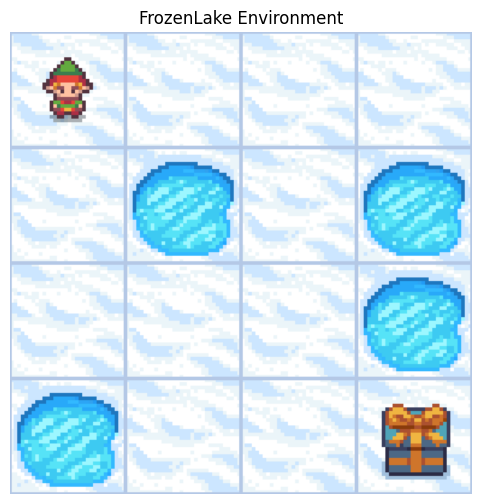

In [ ]:
"""
===========================================
Visualizing FrozenLake Environment
===========================================
"""

import gymnasium as gym
import matplotlib.pyplot as plt

# Create FrozenLake Environment
env = gym.make(
    "FrozenLake-v1",
    render_mode="rgb_array",
    is_slippery=False
)

# Reset Environment
state, info = env.reset()

# Render Environment as Image
image = env.render()

# Display
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("FrozenLake Environment")
plt.axis("off")
plt.show()

env.close()

**Interactiive Session**

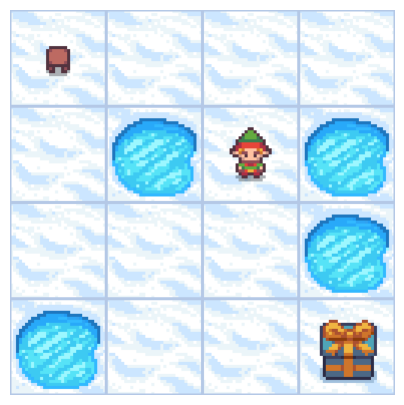

Step          : 4
Current State : 6
Action        : ➡ RIGHT
Next State    : 7
Reward        : 0
Goal Reached? : True

Episode Finished
Final State : 7
Total Reward: 0


In [ ]:
"""
===========================================================
FrozenLake Interaction Loop
Observe:
    • State
    • Action
    • Reward
    • Next State
===========================================================
"""

import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# --------------------------------------------------
# Create Environment
# --------------------------------------------------
env = gym.make(
    "FrozenLake-v1",
    render_mode="rgb_array",
    is_slippery=False      # Easy mode
)

# --------------------------------------------------
# Reset Environment
# --------------------------------------------------
state, info = env.reset()

print("="*60)
print("Episode Started")
print("="*60)

total_reward = 0

action_names = {
    0: "⬅ LEFT",
    1: "⬇ DOWN",
    2: "➡ RIGHT",
    3: "⬆ UP"
}

# --------------------------------------------------
# Run One Episode
# --------------------------------------------------
for step in range(20):

    # Show current environment
    clear_output(wait=True)

    image = env.render()

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("="*50)
    print(f"Step          : {step+1}")
    print(f"Current State : {state}")

    # Random Action
    action = env.action_space.sample()

    print(f"Action        : {action_names[action]}")

    # Environment Response
    next_state, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    print(f"Next State    : {next_state}")
    print(f"Reward        : {reward}")
    print(f"Goal Reached? : {terminated}")

    state = next_state

    time.sleep(1)

    if terminated or truncated:
        break

print("\n===============================")
print("Episode Finished")
print("===============================")

print("Final State :", state)
print("Total Reward:", total_reward)

env.close()

# **Understanding the Q-Table (FrozenLake Environment)**

### **Objective**
- Create an empty **Q-Table**.
- Understand **States** and **Actions**.
- Visualize how the agent stores experience.
- Learn the basic **Q-Learning update formula**.

---

## **Q-Table Formula**

The Q-Table stores the expected reward for taking an action in a particular state.

\[
Q(s,a)
\]

Where:

- **s** = Current State
- **a** = Action
- **Q(s,a)** = Expected Future Reward

---

## **Q-Learning Update Formula**

\[
Q(s,a) \leftarrow Q(s,a)
+\alpha
\left[
r+\gamma\max_aQ(s',a)-Q(s,a)
\right]
\]

Where:

- **α (Alpha)** → Learning Rate
- **γ (Gamma)** → Discount Factor
- **r** → Immediate Reward
- **s′** → Next State
- **max Q(s′,a)** → Best Future Reward

---

## **What is a State?**

A **state** represents the current position of the agent inside the environment.

Example (FrozenLake 4×4):

```text
0   1   2   3
4   5   6   7
8   9  10  11
12 13 14 15
```

There are **16 states (0–15)**.

---

## **What is an Action?**

The agent can perform **4 possible actions**.

| Action | Meaning |
|---------|----------|
| LEFT | Move Left |
| DOWN | Move Down |
| RIGHT | Move Right |
| UP | Move Up |

---

## **Q-Table Size**

For FrozenLake:

- **States = 16**
- **Actions = 4**

Therefore,

```text
Q-Table Shape = 16 × 4
```

Example:

| State | LEFT | DOWN | RIGHT | UP |
|------:|-----:|-----:|------:|---:|
| 0 | 0 | 0 | 0 | 0 |
| 1 | 0 | 0 | 0 | 0 |
| 2 | 0 | 0 | 0 | 0 |
| ... | ... | ... | ... | ... |

Initially, every value is **0**, because the agent has not explored the environment yet.

---

## **Key Points**

- Each **row** represents one **State**.
- Each **column** represents one **Action**.
- Each cell stores the **expected reward** for taking that action from that state.
- During training, the Q-values are updated using the **Q-Learning formula** until the agent learns the optimal policy.

**Understanding the Q-Table**

Environment Information
Total States  : 16
Total Actions : 4

Shape of Q-Table : (16, 4)

Initial Q-Table

    LEFT  DOWN  RIGHT   UP
0    0.0   0.0    0.0  0.0
1    0.0   0.0    0.0  0.0
2    0.0   0.0    0.0  0.0
3    0.0   0.0    0.0  0.0
4    0.0   0.0    0.0  0.0
5    0.0   0.0    0.0  0.0
6    0.0   0.0    0.0  0.0
7    0.0   0.0    0.0  0.0
8    0.0   0.0    0.0  0.0
9    0.0   0.0    0.0  0.0
10   0.0   0.0    0.0  0.0
11   0.0   0.0    0.0  0.0
12   0.0   0.0    0.0  0.0
13   0.0   0.0    0.0  0.0
14   0.0   0.0    0.0  0.0
15   0.0   0.0    0.0  0.0


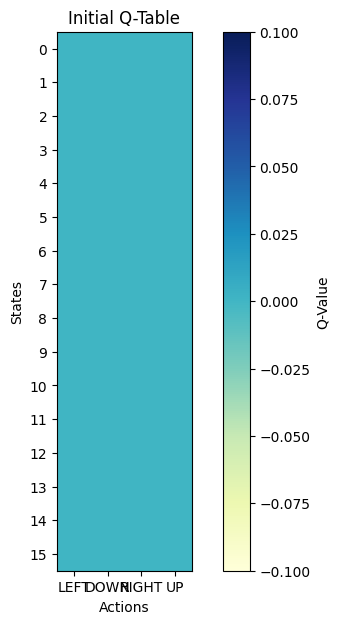

In [ ]:
"""
===========================================================
BLOCK : Understanding the Q-Table
Goal:
    • Create the Q-Table
    • Understand States
    • Understand Actions
    • Observe how values change
===========================================================
"""

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Create Environment
# -------------------------------------------------------
env = gym.make("FrozenLake-v1", is_slippery=False)

# -------------------------------------------------------
# Environment Information
# -------------------------------------------------------
num_states = env.observation_space.n
num_actions = env.action_space.n

print("=" * 60)
print("Environment Information")
print("=" * 60)

print("Total States  :", num_states)
print("Total Actions :", num_actions)

# -------------------------------------------------------
# Create Empty Q-Table
# -------------------------------------------------------
Q = np.zeros((num_states, num_actions))

print("\nShape of Q-Table :", Q.shape)

# -------------------------------------------------------
# Display as Table
# -------------------------------------------------------
actions = ["LEFT", "DOWN", "RIGHT", "UP"]

q_table = pd.DataFrame(Q, columns=actions)

print("\nInitial Q-Table\n")
print(q_table)

# -------------------------------------------------------
# Visualize using Heatmap
# -------------------------------------------------------
plt.figure(figsize=(8,7))

plt.imshow(Q, cmap="YlGnBu")

plt.colorbar(label="Q-Value")

plt.xticks(range(num_actions), actions)

plt.yticks(range(num_states))

plt.xlabel("Actions")
plt.ylabel("States")
plt.title("Initial Q-Table")

plt.show()

env.close()

**First Q-Value Update (Manual)**

In [ ]:
"""
===========================================================
BLOCK : First Q-Value Update (Manual)
===========================================================
"""

import gymnasium as gym
import numpy as np
import pandas as pd

# Environment
env = gym.make("FrozenLake-v1", is_slippery=False)

num_states = env.observation_space.n
num_actions = env.action_space.n

# Empty Q-table
Q = np.zeros((num_states, num_actions))

actions = ["LEFT", "DOWN", "RIGHT", "UP"]

print("\nInitial Q-Table\n")
print(pd.DataFrame(Q, columns=actions))

# ----------------------------------------------------
# Example Experience
# ----------------------------------------------------
state = 0
action = 2          # RIGHT
reward = 1          # Assume reaching a good state

print("\nExample Experience")
print("---------------------------")
print("Current State :", state)
print("Action        : RIGHT")
print("Reward        :", reward)

# Update ONE Cell
Q[state, action] = reward

print("\nUpdated Q-Table\n")
print(pd.DataFrame(Q, columns=actions))

print("\nUpdated Cell")
print(f"Q[{state}, RIGHT] = {Q[state, action]}")


Initial Q-Table

    LEFT  DOWN  RIGHT   UP
0    0.0   0.0    0.0  0.0
1    0.0   0.0    0.0  0.0
2    0.0   0.0    0.0  0.0
3    0.0   0.0    0.0  0.0
4    0.0   0.0    0.0  0.0
5    0.0   0.0    0.0  0.0
6    0.0   0.0    0.0  0.0
7    0.0   0.0    0.0  0.0
8    0.0   0.0    0.0  0.0
9    0.0   0.0    0.0  0.0
10   0.0   0.0    0.0  0.0
11   0.0   0.0    0.0  0.0
12   0.0   0.0    0.0  0.0
13   0.0   0.0    0.0  0.0
14   0.0   0.0    0.0  0.0
15   0.0   0.0    0.0  0.0

Example Experience
---------------------------
Current State : 0
Action        : RIGHT
Reward        : 1

Updated Q-Table

    LEFT  DOWN  RIGHT   UP
0    0.0   0.0    1.0  0.0
1    0.0   0.0    0.0  0.0
2    0.0   0.0    0.0  0.0
3    0.0   0.0    0.0  0.0
4    0.0   0.0    0.0  0.0
5    0.0   0.0    0.0  0.0
6    0.0   0.0    0.0  0.0
7    0.0   0.0    0.0  0.0
8    0.0   0.0    0.0  0.0
9    0.0   0.0    0.0  0.0
10   0.0   0.0    0.0  0.0
11   0.0   0.0    0.0  0.0
12   0.0   0.0    0.0  0.0
13   0.0   0.0    0.0

**Complete Q-Learning Training (FrozenLake)**

Learned Q-Table
[[0.74 0.77 0.7  0.74]
 [0.74 0.   0.63 0.7 ]
 [0.7  0.69 0.4  0.53]
 [0.63 0.   0.   0.  ]
 [0.77 0.81 0.   0.74]
 [0.   0.   0.   0.  ]
 [0.   0.9  0.   0.65]
 [0.   0.   0.   0.  ]
 [0.81 0.   0.86 0.77]
 [0.81 0.81 0.9  0.  ]
 [0.86 0.95 0.   0.86]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.81 0.76 0.86]
 [0.81 0.95 1.   0.9 ]
 [0.   0.   0.   0.  ]]

Best Action for Every State

State  0 ---> ↓
State  1 ---> ←
State  2 ---> ←
State  3 ---> ←
State  4 ---> ↓
State  5 ---> ←
State  6 ---> ↓
State  7 ---> ←
State  8 ---> →
State  9 ---> →
State 10 ---> ↓
State 11 ---> ←
State 12 ---> ←
State 13 ---> ↑
State 14 ---> →
State 15 ---> ←


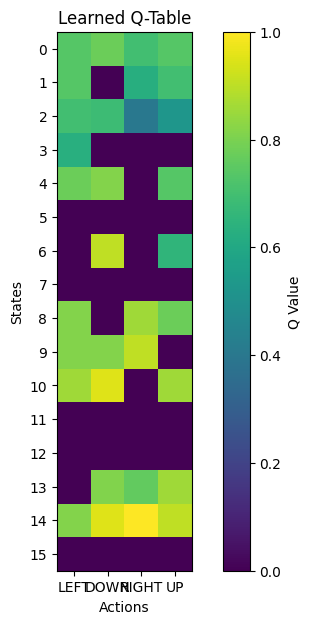

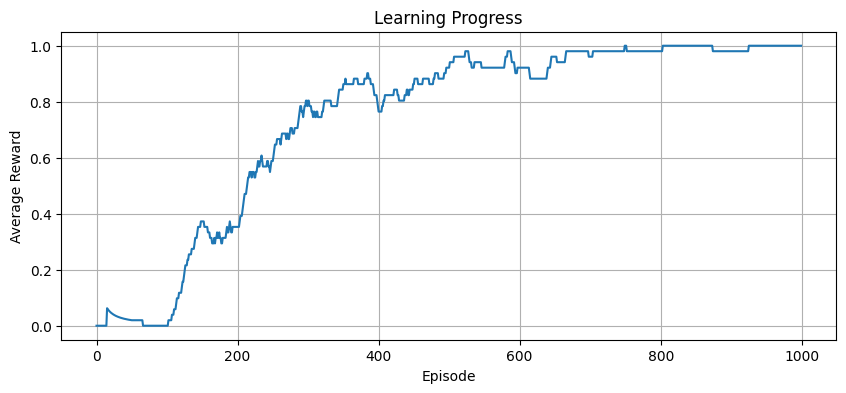

In [ ]:
"""
===========================================================
BLOCK : Q-Learning Training on FrozenLake
===========================================================

Goal:
    Learn the best path from Start → Goal

"""

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Create Environment
# ---------------------------------------------------
env = gym.make(
    "FrozenLake-v1",
    is_slippery=False
)

# ---------------------------------------------------
# Environment Information
# ---------------------------------------------------
num_states = env.observation_space.n
num_actions = env.action_space.n

# ---------------------------------------------------
# Initialize Q Table
# ---------------------------------------------------
Q = np.zeros((num_states, num_actions))

# ---------------------------------------------------
# Hyperparameters
# ---------------------------------------------------
learning_rate = 0.8      # α
discount = 0.95          # γ

epsilon = 1.0            # Exploration
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 1000
max_steps = 100

reward_history = []

# ---------------------------------------------------
# Training
# ---------------------------------------------------
for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):

        # -------------------------------------------
        # Choose Action
        # -------------------------------------------
        if np.random.rand() < epsilon:

            # Explore
            action = env.action_space.sample()

        else:

            # Exploit
            action = np.argmax(Q[state])

        # -------------------------------------------
        # Take Action
        # -------------------------------------------
        next_state, reward, terminated, truncated, info = env.step(action)

        # -------------------------------------------
        # Q-Learning Formula
        # -------------------------------------------
        Q[state, action] = Q[state, action] + learning_rate * (
                reward +
                discount * np.max(Q[next_state]) -
                Q[state, action]
        )

        state = next_state

        total_reward += reward

        if terminated or truncated:
            break

    reward_history.append(total_reward)

    # Reduce Exploration
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

env.close()

# ---------------------------------------------------
# Learned Q Table
# ---------------------------------------------------
print("="*70)
print("Learned Q-Table")
print("="*70)

np.set_printoptions(precision=2, suppress=True)
print(Q)

# ---------------------------------------------------
# Best Action in Every State
# ---------------------------------------------------
action_names = np.array(["←","↓","→","↑"])

policy = action_names[np.argmax(Q, axis=1)]

print("\nBest Action for Every State\n")

for s in range(num_states):
    print(f"State {s:2d} ---> {policy[s]}")

# ---------------------------------------------------
# Heatmap of Q Table
# ---------------------------------------------------
plt.figure(figsize=(8,7))

plt.imshow(Q, cmap="viridis")

plt.colorbar(label="Q Value")

plt.xticks(
    range(4),
    ["LEFT","DOWN","RIGHT","UP"]
)

plt.yticks(range(16))

plt.xlabel("Actions")
plt.ylabel("States")

plt.title("Learned Q-Table")

plt.show()

# ---------------------------------------------------
# Training Progress
# ---------------------------------------------------
window = 50

avg_rewards = [
    np.mean(reward_history[max(0,i-window):i+1])
    for i in range(len(reward_history))
]

plt.figure(figsize=(10,4))

plt.plot(avg_rewards)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title("Learning Progress")

plt.grid(True)

plt.show()

**Test the Trained Q-Learning Agent**

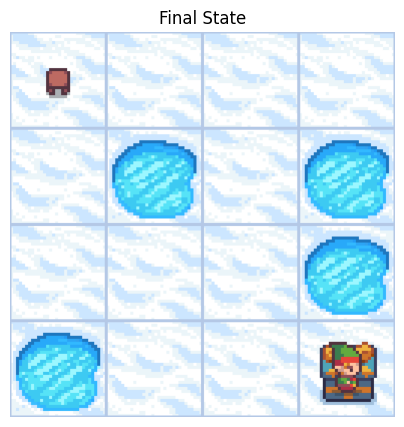

🎉 Goal Reached Successfully!

Total Reward : 1


In [ ]:
"""
===========================================================
BLOCK : Test the Trained Q-Learning Agent

No Learning
No Exploration

The agent only uses the learned Q-table.
===========================================================
"""

import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import time

# -------------------------------------------------
# Create Environment
# -------------------------------------------------
env = gym.make(
    "FrozenLake-v1",
    render_mode="rgb_array",
    is_slippery=False
)

# -------------------------------------------------
# Reset
# -------------------------------------------------
state, info = env.reset()

action_names = {
    0: "⬅ LEFT",
    1: "⬇ DOWN",
    2: "➡ RIGHT",
    3: "⬆ UP"
}

total_reward = 0

print("="*60)
print("TRAINED AGENT PLAYING")
print("="*60)

# -------------------------------------------------
# Play
# -------------------------------------------------
for step in range(30):

    clear_output(wait=True)

    image = env.render()

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Step {step+1}")
    plt.show()

    print(f"Current State : {state}")

    # -------------------------------
    # BEST ACTION FROM Q TABLE
    # -------------------------------
    action = np.argmax(Q[state])

    print(f"Chosen Action : {action_names[action]}")

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"Next State    : {next_state}")
    print(f"Reward        : {reward}")

    total_reward += reward

    state = next_state

    time.sleep(1)

    if terminated or truncated:

        clear_output(wait=True)

        image = env.render()

        plt.figure(figsize=(5,5))
        plt.imshow(image)
        plt.axis("off")
        plt.title("Final State")
        plt.show()

        if reward == 1:
            print("🎉 Goal Reached Successfully!")
        else:
            print("❌ Fell Into Hole!")

        break

print("\nTotal Reward :", total_reward)

env.close()

In [ ]:
"""
=========================================================
Why Q-Learning Fails
=========================================================
"""

import numpy as np

# FrozenLake
states = 16
actions = 4

q_table = np.zeros((states, actions))

print("="*60)
print("FrozenLake")
print("="*60)

print("States :", states)
print("Actions:", actions)
print("Q Table Shape:", q_table.shape)

print()

# Atari Example

states = 210 * 160 * 3

print("="*60)
print("Atari Game")
print("="*60)

print("Image Pixels :", states)
print("Possible Actions : 18")

print()

print("Imagine making a Q Table...")

print(f"Rows = {states:,}")
print("Columns = 18")

print("\nImpossible ❌")

print("""
Reason:

Every image is a different state.

Millions of states

Infinite possibilities

Q-Table cannot store everything.
""")

FrozenLake
States : 16
Actions: 4
Q Table Shape: (16, 4)

Atari Game
Image Pixels : 100800
Possible Actions : 18

Imagine making a Q Table...
Rows = 100,800
Columns = 18

Impossible ❌

Reason:

Every image is a different state.

Millions of states

Infinite possibilities

Q-Table cannot store everything.



# **Deep Q Networking**

In [ ]:
# Install the Required Libraries
!pip install gymnasium tensorflow numpy

**Create the CartPole Environment for Deep Q-Network (DQN)**

In [ ]:


# Import the Required Libraries
import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create the CartPole Environment
env = gym.make("CartPole-v1")

state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

print("State Size:", state_size)
print("Action Size:", action_size)


**Build the Deep Q-Network (DQN) Model**

In [ ]:
# Build the Deep Q-Network
model = Sequential([
    Dense(24, activation="relu", input_shape=(state_size,)),
    Dense(action_size, activation="linear")
])

model.compile(optimizer="adam", loss="mse")

# Define the Hyperparameters
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.01
episodes = 50

**Training**

In [ ]:
# Train the DQN Agent
for episode in range(episodes):

    state, _ = env.reset()
    state = state.reshape(1, state_size)

    done = False

    while not done:

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(model.predict(state, verbose=0))

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = next_state.reshape(1, state_size)

        target = reward
        if not done:
            target += gamma * np.max(model.predict(next_state, verbose=0))

        q_values = model.predict(state, verbose=0)
        q_values[0][action] = target

        model.fit(state, q_values, epochs=1, verbose=0)
        state = next_state

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    print(f"Episode {episode+1} completed")

AttributeError: 'int' object has no attribute 'reshape'

**Testing the Agent**

In [ ]:
# Test the Trained Agent
state, _ = env.reset()
state = state.reshape(1, state_size)

done = False
total_reward = 0

while not done:

    action = np.argmax(model.predict(state, verbose=0))

    next_state, reward, terminated, truncated, _ = env.step(action)

    total_reward += reward
    state = next_state.reshape(1, state_size)
    done = terminated or truncated

print("Total Reward:", total_reward)

**Visualization**

In [ ]:
# ==========================================
# Visualization 1: Q-Values for One State
# ==========================================

import matplotlib.pyplot as plt

state, _ = env.reset()
state = state.reshape(1, state_size)

q_values = model.predict(state, verbose=0)[0]

actions = ["Left", "Right"]

plt.figure(figsize=(6,4))
plt.bar(actions, q_values)
plt.ylabel("Predicted Q-Value")
plt.title("Q-Values Predicted by DQN")
plt.show()

print("Q Values:", q_values)
print("Chosen Action:", actions[np.argmax(q_values)])

**Loop Results**

In [ ]:
episode_rewards = []

for episode in range(episodes):

    state, _ = env.reset()
    state = state.reshape(1, state_size)

    done = False
    total_reward = 0

    while not done:

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(model.predict(state, verbose=0))

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        total_reward += reward

        next_state = next_state.reshape(1, state_size)

        target = reward

        if not done:
            target += gamma * np.max(model.predict(next_state, verbose=0))

        q_values = model.predict(state, verbose=0)
        q_values[0][action] = target

        model.fit(state, q_values, epochs=1, verbose=0)

        state = next_state

    episode_rewards.append(total_reward)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    print(f"Episode {episode+1}: Reward = {total_reward}")

**DQN Learning Curve**

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(episode_rewards, linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Learning Curve")
plt.grid(True)
plt.show()

# Proximal Policy Optimization

In [ ]:
# Install Libraries
!pip install stable-baselines3 gymnasium

# Import Libraries
import gymnasium as gym
from stable_baselines3 import PPO

**Creating Environment**

In [ ]:
# Create the Environment
env = gym.make("CartPole-v1")

# Initialize the PPO Model
model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

**Training Agent**

In [ ]:
# Train the Agent
model.learn(total_timesteps=20000)

#  Save the Trained Model
model.save("ppo_cartpole")

# Test the Trained Agent
obs, info = env.reset()

for _ in range(500):

    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    env.render()

    if done:
        obs, info = env.reset()

env.close()
print("Training Complete!")

**Reward Visualization**

In [ ]:
# ============================================
# PPO Training with Reward Visualization
# ============================================

# Install (if needed)
# !pip install stable-baselines3 gymnasium matplotlib pandas

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# --------------------------------------------
# Create Environment with Monitor
# --------------------------------------------

env = Monitor(
    gym.make("CartPole-v1"),
    filename="monitor.csv"      # Save training log
)

# --------------------------------------------
# Create PPO Model
# --------------------------------------------

model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

# --------------------------------------------
# Train the Agent
# --------------------------------------------

model.learn(total_timesteps=20000)

# Save Model
model.save("ppo_cartpole")

print("Training Finished!")

# --------------------------------------------
# Load Reward Log
# --------------------------------------------

log = pd.read_csv("monitor.csv", skiprows=1)

print(log.head())

# --------------------------------------------
# Plot Reward Curve
# --------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    log["r"],
    linewidth=2,
    color="blue"
)

plt.title("PPO Learning Curve (Episode Reward)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)

plt.show()

**Animation**

In [ ]:
# ============================================
# Live CartPole Animation after PPO Training
# ============================================

import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from stable_baselines3 import PPO

# Create Environment with Rendering
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Load trained model
model = PPO.load("ppo_cartpole")

# Reset
obs, info = env.reset()

frames = []

# Run one episode
done = False

while not done:

    # Store current frame
    frame = env.render()
    frames.append(frame)

    # Predict action
    action, _ = model.predict(obs, deterministic=True)

    # Step
    obs, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

env.close()

# ============================================
# Create Animation
# ============================================

fig = plt.figure(figsize=(6,6))

plt.axis("off")

im = plt.imshow(frames[0])

def update(frame):
    im.set_array(frame)
    return [im]

ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=30,
    blit=True
)

HTML(ani.to_jshtml())